# Do other models' translations agree? A consensus metric for NL→FOL faithfulness

This notebook is a runnable demo of **Experiment 3 (candidate C)**. The metric scores a candidate first-order-logic (FOL) translation of a
natural-language sentence **without a gold formula and without reading the text**. It only asks: *do other systems' translations of the same
sentence mean the same thing?*

For a candidate `c` of sentence `t`, the **pool** holds every *other* system's translation of `t`, leaving out `c`'s own system:

* 6 fresh OpenRouter model families: P1 llama-3.3-70b, P2 qwen3-235b, P3 deepseek-v3.1, P4 mistral-small-3.2, P5 gemini-2.5-flash-lite, P6 gpt-4.1-mini;
* the 3 released Logic-LM systems: gpt-3.5-turbo, gpt-4 and text-davinci-003.

| score (higher = more likely an error) | definition |
|---|---|
| **`c_score`** (primary) | `1 - eq_frac`: the share of pool members that are **not** z3-equivalent to `c` *modulo vocabulary*. `eqmv` tries exact z3 equivalence first, then an `align()` predicate/constant renaming, then a merge/split `gran_bridge`. |
| `medoid_depth` / `medoid_ops` | the minimal typed repair (0–3 edits) that turns `c` into the pool medoid. The operators say what kind of error it is. |
| `cluster_entropy` | the semantic entropy of the z3-eqmv equivalence classes of pool ∪ {c} |
| `sc5_cheap` / `sc5_same` (baselines) | the same agreement, but against K=5 self-consistency samples (gpt-4.1-nano, or gpt-3.5-turbo for gpt-3.5 candidates) |
| `predset_instab_*`, `fol_length` (baselines) | predicate-name Jaccard instability, and the number of atoms |

**Ground truth.** Each candidate was labelled CORRECT or ERROR by prover-checked equivalence to the *corrected* FOLIO gold, after vocabulary
alignment (the census labeller `label()`, also included below).

**Full-run headline** (track L, 297 CORRECT vs 249 ERROR, sentence-clustered bootstrap):

* c_score AUROC **0.866 [0.821, 0.906]**, against 0.725 for sc5_cheap;
* paired Δ = +0.140 [0.085, 0.197];
* 38% of errors are endorsed by the consensus (a shared blind spot);
* RENAME rewrites produce 96% false alarms.

**This demo.** The LLM calls (about $1.52 on OpenRouter) are *not* repeated. `mini_demo_data.json` ships the translations they returned (the peer
pools and the SC samples) for a random subset of **35 sentences / 100 track-L candidates**. Everything downstream is re-run from those strings: the
z3 equivalence checks, the consensus scores, the medoid repairs, the rewrite and planted-error checks, and the AUROC analysis.

The original pipeline (`method.py`) runs these stages in order:
`tests → screen.py → peers.py (API) → consensus.py → analysis.py`.
The cells below are the code of `fol.py`, `repair_census.py`, `common.py`, `eqcache.py`, `rewrites.py`, `consensus.py` and `analysis.py`, copied
as-is except for file I/O.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib, nltk — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0', 'nltk==3.9.1')

In [2]:
# ---- imports of the original modules (fol.py, repair_census.py, common.py, consensus.py, rewrites.py, analysis.py)
from __future__ import annotations

import argparse
import hashlib
import itertools
import json
import math
import random
import re
import sys
import time
from collections import Counter, defaultdict
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import z3
from loguru import logger
from scipy.stats import rankdata, spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold

# ---- extra imports for the notebook (visualisation)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

sys.setrecursionlimit(10000)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-1/experiment-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"{len(data['sentences'])} sentences, {len(data['items'])} candidates;", dict(Counter(x['label'] for x in data['items'])))
print("peer models:", data["peer_models"])

35 sentences, 100 candidates; {'CORRECT': 53, 'ERROR': 47}
peer models: {'P1': 'meta-llama/llama-3.3-70b-instruct', 'P2': 'qwen/qwen3-235b-a22b-2507', 'P3': 'deepseek/deepseek-chat-v3.1', 'P4': 'mistralai/mistral-small-3.2-24b-instruct', 'P5': 'google/gemini-2.5-flash-lite', 'P6': 'openai/gpt-4.1-mini'}


## Configuration

Every tunable parameter is set here. The comments give the original full-run values.

In [5]:
N_SENTENCES = 35        # sentences to score (the mini data has 35; original screen: all 1,040 sentences / 1,169 candidates)
REPAIR_BUDGET_S = 10.0  # seconds per medoid typed-repair search (original: consensus.py --budget 10.0)
LABEL_BUDGET_S = 25.0   # seconds per labeller repair search, used for the medoid labels (original: 25.0)
N_REWRITE = 150         # CORRECT candidates used for the rewrite-invariance test (original: 150; the demo has 53 CORRECT)
N_PLANTED = 30          # planted DROP/NEG errors (original: 30)
BOOT = 2000             # sentence-clustered bootstrap resamples for the CIs (original: analysis.py --boot 2000)
N_LABEL_CHECK = 20      # candidates re-labelled from scratch to show the labeller reproduces the stored labels (original labels all 1,575 pairs)

## 1. `fol.py`: parsing FOLIO/MALLS Unicode FOL and translating it to z3

The recursive-descent parser turns strings such as `∀x (Dog(x) → ¬Cat(x))` into a tuple AST. `to_z3` maps the AST into z3 over one
uninterpreted sort `U`. `equivalent(e1, e2)` proves `e1 ↔ e2` valid, which is the basic check the metric uses. The precedence fix is:
⊕ binds like ∨, so `A ⊕ B → C` parses as `(A ⊕ B) → C`.

In [6]:
import re
import z3

TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("->", "→").replace("<->", "↔").replace("&", "∧").replace("|", "∨")
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def profile(e, ms=3000):
    """Semantic monotonicity of formula e in each predicate: UP / DOWN / VACUOUS / NONMONO / UNKNOWN."""
    ar = preds(e)
    base = {q: mkpred(q, m) for q, m in ar.items()}
    out = {}
    for p, n in ar.items():
        alt = dict(base)
        alt[p] = mkpred(p + "_prime", n)
        xs = [z3.Const(f"_x{i}", U) for i in range(n)]
        sub = z3.ForAll(xs, z3.Implies(base[p](*xs), alt[p](*xs))) if n else z3.Implies(base[p], alt[p])
        F, Fp = to_z3(e, {}, base), to_z3(e, {}, alt)
        up, down = valid(z3.Implies(z3.And(sub, F), Fp), ms), valid(z3.Implies(z3.And(sub, Fp), F), ms)
        if up is None or down is None:
            out[p] = "UNKNOWN"
        else:
            out[p] = {(True, True): "VACUOUS", (True, False): "UP", (False, True): "DOWN", (False, False): "NONMONO"}[(up, down)]
    return out


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)


def connectivity_flags(e):
    """Binding check: inside each quantifier scope, variables must be linked through shared atoms.
    Returns list of variables that are quantified but share no atom with any other variable in the
    same top-level sentence while other variables exist (an 'island')."""
    atoms = []

    def walk(x):
        if x[0] == "atom":
            atoms.append(set(a for a in x[2]))
        elif x[0] in ("all", "ex"):
            walk(x[2])
        elif x[0] == "not":
            walk(x[1])
        else:
            walk(x[1]); walk(x[2])

    def qvars(x, acc):
        if x[0] in ("all", "ex"):
            acc.append(x[1]); qvars(x[2], acc)
        elif x[0] == "not":
            qvars(x[1], acc)
        elif x[0] != "atom":
            qvars(x[1], acc); qvars(x[2], acc)
        return acc

    walk(e)
    vs = qvars(e, [])
    if len(vs) < 2:
        return []
    # union-find over variables via atoms
    parent = {v: v for v in vs}

    def f(v):
        while parent[v] != v:
            v = parent[v]
        return v
    for a in atoms:
        a = [v for v in a if v in parent]
        for v in a[1:]:
            parent[f(v)] = f(a[0])
    comps = {}
    for v in vs:
        comps.setdefault(f(v), []).append(v)
    if len(comps) == 1:
        return []
    main = max(comps.values(), key=len)
    return [v for c in comps.values() if c is not main for v in c]


def prenex_blocks(e):
    """Split a formula into top-level conjuncts; for each, collect its leading quantifier block."""
    parts = []

    def flat(x):
        if x[0] == "and":
            flat(x[1]); flat(x[2])
        else:
            parts.append(x)
    flat(e)
    return parts


def coupled_independent_vars(e):
    """GLUE check: within ONE top-level conjunct, >=2 universally quantified variables that never
    co-occur in any atom, i.e. independent generic claims wrongly bundled under a joint quantifier
    ('∀x∀y (Wolf(x) ∧ Bird(y) → Howls(x) ∧ Chirps(y))'). Returns True if any conjunct has one."""
    for part in prenex_blocks(e):
        if connectivity_flags(part):
            return True
    return False


def token_profile(prof):
    """Project a predicate-level polarity profile onto CamelCase word tokens, so that merged
    (WorksInNewsIndustryAndReportsOnEvents) and split (WorksInNewsIndustry ∧ ReportsOnEvents)
    renderings of the same concept get the same profile."""
    import re as _re
    STOP = {"and", "or", "of", "in", "on", "the", "a", "an", "to", "is", "has", "have", "can", "for", "with", "by", "at", "from"}
    out = {}
    for key, pol in prof.items():
        name = key.split("/")[0]
        for w in _re.findall(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+", name):
            w = w.lower()
            if w in STOP:
                continue
            w = w[:-1] if w.endswith("s") and len(w) > 3 else w
            out.setdefault(w, set()).add(pol)
    return out

## 2. `repair_census.py`: vocabulary alignment, granularity bridges and typed repair search

These are the building blocks of `eqmv` and of the labeller:

* **`align(old, new)`**: renames the predicates and constants of `old` onto those of `new` when they have the same arity and are similar enough.
  Similar means CamelCase-token Jaccard ≥ 0.5, or char-trigram Dice ≥ 0.6, or normalised string containment for constants.
* **`gran_bridge`**: a definitional merge/split, e.g. `P(x) := Q1(x) ∧ Q2(x)` when tokens(P) = tokens(Q1) + tokens(Q2), plus reification.
* **`fp(e)`**: a random-model fingerprint over 24 seeded 3-element models. It is a cheap, sound *necessary* condition for equivalence that
  pre-filters z3 calls. It uses Python `hash()`, so it is consistent within one process. The original pipeline pins `PYTHONHASHSEED=0`; a notebook kernel
  cannot. That does not change `fp`, but it can change which constant `align()` picks when two constants tie, since it iterates over a set.
  So an occasional `eqmv` verdict can differ from the full run's (1 of 100 candidates here).
* **`edits` / `search`**: breadth-first search, depth ≤ 2, over typed operators (NEG, REV, QUANT, RESTR, CONN, DROP, ADD, SWAP, BIND, SCOPE,
  UNGLUE, MOVE). It finds the smallest edit that makes a formula z3-equivalent to a target. The operator multiset is the error type.

(The census driver `pairs()/work()/main()` of the original file reads iteration-3 data files and is not needed here.)

In [7]:
TOKRE = re.compile(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+")
STOP = {"and", "or", "of", "in", "on", "the", "a", "an", "to", "is", "has", "have", "can", "for", "with", "by", "at", "from", "be", "are"}
BIN = ("and", "or", "imp", "iff", "xor")


def toks(name):
    out = []
    for w in TOKRE.findall(name.replace("_", " ")):
        w = w.lower()
        if w in STOP:
            continue
        out.append(w[:-1] if w.endswith("s") and len(w) > 3 else w)
    return out


def tri(s):
    s = re.sub(r"[^a-z0-9]", "", s.lower())
    return {s[i:i + 3] for i in range(max(1, len(s) - 2))}


def dice(a, b):
    A, B = tri(a), tri(b)
    return 2 * len(A & B) / max(1, len(A) + len(B))


# ---------------------------------------------------------------- AST utilities
def atoms(e, acc=None):
    acc = [] if acc is None else acc
    if e[0] == "atom":
        acc.append(e)
    elif e[0] in ("all", "ex"):
        atoms(e[2], acc)
    elif e[0] == "not":
        atoms(e[1], acc)
    else:
        atoms(e[1], acc); atoms(e[2], acc)
    return acc


def bound_vars(e, acc=None):
    acc = set() if acc is None else acc
    if e[0] in ("all", "ex"):
        acc.add(e[1]); bound_vars(e[2], acc)
    elif e[0] == "not":
        bound_vars(e[1], acc)
    elif e[0] != "atom":
        bound_vars(e[1], acc); bound_vars(e[2], acc)
    return acc


def symbols(e):
    bv = bound_vars(e)
    P, C = {}, set()
    for a in atoms(e):
        P[(a[1], len(a[2]))] = True
        for x in a[2]:
            if x not in bv:
                C.add(x)
    return set(P), C


def rename(e, pmap, cmap, bv=frozenset()):
    k = e[0]
    if k == "atom":
        return ("atom", pmap.get((e[1], len(e[2])), e[1]), tuple(x if x in bv else cmap.get(x, x) for x in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], rename(e[2], pmap, cmap, bv | {e[1]}))
    if k == "not":
        return ("not", rename(e[1], pmap, cmap, bv))
    return (k, rename(e[1], pmap, cmap, bv), rename(e[2], pmap, cmap, bv))


def expand(e, defs):
    """defs: {(name, arity): [name1, name2]}  P(args) -> Q1(args) & Q2(args)"""
    k = e[0]
    if k == "atom":
        key = (e[1], len(e[2]))
        if key in defs:
            q = defs[key]
            out = ("atom", q[0], e[2])
            for n in q[1:]:
                out = ("and", out, ("atom", n, e[2]))
            return out
        return e
    if k in ("all", "ex"):
        return (k, e[1], expand(e[2], defs))
    if k == "not":
        return ("not", expand(e[1], defs))
    return (k, expand(e[1], defs), expand(e[2], defs))


def align(old, new):
    Po, Co = symbols(old)
    Pn, Cn = symbols(new)
    pmap, used = {}, set()
    cands = []
    for p in Po - Pn:
        for q in Pn - Po:
            if p[1] != q[1]:
                continue
            to, tn = set(toks(p[0])), set(toks(q[0]))
            j = len(to & tn) / max(1, len(to | tn))
            s = max(j, dice(p[0], q[0]))
            if p[0].lower() == q[0].lower():
                s = 2
            if j >= 0.5 or dice(p[0], q[0]) >= 0.6 or s == 2:
                cands.append((s, p, q))
    for s, p, q in sorted(cands, reverse=True):
        if p in pmap or q in used:
            continue
        pmap[p] = q[0]; used.add(q)
    cmap, cused = {}, set()
    norm = lambda s: re.sub(r"[^a-z0-9]", "", s.lower())
    for c in Co - Cn:
        best = None
        for d in Cn - Co:
            if d in cused:
                continue
            a, b = norm(c), norm(d)
            if a == b or (min(len(a), len(b)) >= 4 and (a in b or b in a)) or dice(c, d) >= 0.7:
                best = d
                break
        if best:
            cmap[c] = best; cused.add(best)
    return rename(old, pmap, cmap), pmap, cmap


def gran_bridge(ao, new):
    """Try merge/split definitional bridges between leftover predicates of the aligned original and corrected."""
    Po, _ = symbols(ao)
    Pn, _ = symbols(new)
    lo, ln = Po - Pn, Pn - Po
    defs_old, defs_new = {}, {}
    for p in lo:  # original merged predicate -> corrected split pair
        tp = sorted(toks(p[0]))
        for q1, q2 in itertools.combinations([q for q in ln if q[1] == p[1]], 2):
            if sorted(toks(q1[0]) + toks(q2[0])) == tp or set(toks(q1[0]) + toks(q2[0])) == set(tp):
                defs_old[p] = [q1[0], q2[0]]
    for q in ln:  # corrected merged predicate -> original split pair
        tq = sorted(toks(q[0]))
        for p1, p2 in itertools.combinations([p for p in lo if p[1] == q[1]], 2):
            if sorted(toks(p1[0]) + toks(p2[0])) == tq or set(toks(p1[0]) + toks(p2[0])) == set(tq):
                defs_new[q] = [p1[0], p2[0]]
    _, Cn = symbols(new)
    reify = {}
    for p in lo:  # P(x) := Q(x, c) when tokens(P) == tokens(Q) + tokens(c)
        for q in ln:
            if q[1] != p[1] + 1:
                continue
            for c in Cn:
                if set(toks(q[0]) + toks(c)) == set(toks(p[0])):
                    reify[p] = (q[0], c)
    if not defs_old and not defs_new and not reify:
        return None
    return reify_expand(expand(ao, defs_old), reify), expand(new, defs_new)


def reify_expand(e, reify):
    k = e[0]
    if k == "atom":
        key = (e[1], len(e[2]))
        if key in reify:
            q, c = reify[key]
            return ("atom", q, e[2] + (c,))
        return e
    if k in ("all", "ex"):
        return (k, e[1], reify_expand(e[2], reify))
    if k == "not":
        return ("not", reify_expand(e[1], reify))
    return (k, reify_expand(e[1], reify), reify_expand(e[2], reify))


# ---------------------------------------------------------------- random-model fingerprint (necessary condition)
SEEDS = list(range(24))


def ev(e, m, env, dom, seed):
    k = e[0]
    if k == "atom":
        args = tuple(env[x] if x in env else (hash((seed, "c", x)) % dom) for x in e[2])
        return (hash((seed, e[1], len(e[2]), args)) >> 3) & 1 == 1
    if k == "all":
        return all(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "ex":
        return any(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "not":
        return not ev(e[1], m, env, dom, seed)
    a, b = ev(e[1], m, env, dom, seed), ev(e[2], m, env, dom, seed)
    return {"and": a and b, "or": a or b, "imp": (not a) or b, "iff": a == b, "xor": a != b}[k]


def fp(e):
    return tuple(ev(e, None, {}, 3, s) for s in SEEDS)


# ---------------------------------------------------------------- typed operators
def subterms(e, path=(), scope=()):
    yield path, e, scope
    k = e[0]
    if k in ("all", "ex"):
        yield from subterms(e[2], path + (2,), scope + (e[1],))
    elif k == "not":
        yield from subterms(e[1], path + (1,), scope)
    elif k != "atom":
        yield from subterms(e[1], path + (1,), scope)
        yield from subterms(e[2], path + (2,), scope)


def replace(e, path, new):
    if not path:
        return new
    i = path[0]
    lst = list(e)
    lst[i] = replace(e[i], path[1:], new)
    return tuple(lst)


def parent_kind(e, path):
    if not path:
        return None
    x = e
    for i in path[:-1]:
        x = x[i]
    return x[0]


def unglue(node):
    """∀x∀y (A(x) ∧ B(y) → C(x) ∧ D(y))  ->  ∀x (A(x) → C(x)) ∧ ∀y (B(y) → D(y))"""
    vs, body = [], node
    while body[0] == "all":
        vs.append(body[1]); body = body[2]
    if len(vs) < 2 or body[0] != "imp":
        return None

    def conj(x):
        return conj(x[1]) + conj(x[2]) if x[0] == "and" else [x]

    def vars_of(x):
        return {a for at in atoms(x) for a in at[2] if a in vs}
    ant, con = conj(body[1]), conj(body[2])
    groups = []
    for v in vs:
        a = [x for x in ant if vars_of(x) == {v}]
        c = [x for x in con if vars_of(x) == {v}]
        if not c:
            return None
        groups.append((v, a, c))
    if sum(len(g[1]) for g in groups) != len(ant) or sum(len(g[2]) for g in groups) != len(con):
        return None

    def mk(lst, op="and"):
        out = lst[0]
        for x in lst[1:]:
            out = (op, out, x)
        return out
    parts = [("all", v, ("imp", mk(a), mk(c)) if a else mk(c)) for v, a, c in groups]
    return mk(parts)


def edits(e, target):
    """Yield (op_label, candidate) for every single typed edit of e."""
    tgt_atoms = atoms(target)
    Pe, _ = symbols(e)
    _, Ct = symbols(target)
    new_atoms = [a for a in tgt_atoms if (a[1], len(a[2])) not in Pe]
    for path, node, scope in list(subterms(e)):
        k = node[0]
        # NEG
        if k == "not":
            yield "NEG", replace(e, path, node[1])
        else:
            yield "NEG", replace(e, path, ("not", node))
        if k in ("all", "ex"):
            yield "QUANT", replace(e, path, ("ex" if k == "all" else "all", node[1], node[2]))
            # block flip with the restrictor convention: ∀x∀y(A→B) <-> ∃x∃y(A∧B)
            vs, body = [], node
            while body[0] == k:
                vs.append(body[1]); body = body[2]
            if body[0] in ("imp", "and"):
                nb = ("and" if body[0] == "imp" else "imp", body[1], body[2])
                q = "ex" if k == "all" else "all"
                for v in reversed(vs):
                    nb = (q, v, nb)
                yield "QUANT", replace(e, path, nb)
            if node[2][0] in ("all", "ex"):
                inner = node[2]
                yield "SCOPE", replace(e, path, (inner[0], inner[1], (k, node[1], inner[2])))
            ug = unglue(node) if k == "all" else None
            if ug is not None:
                yield "UNGLUE", replace(e, path, ug)
        if k in ("imp", "iff") and node[1][0] == "and":
            # MOVE: pull a conjunct of the left side out as an outer restriction: (A ∧ B op C) -> (A -> (B op C))
            yield "MOVE", replace(e, path, ("imp", node[1][1], (k, node[1][2], node[2])))
            yield "MOVE", replace(e, path, ("imp", node[1][2], (k, node[1][1], node[2])))
        if k == "imp" and node[2][0] == "imp":
            # MOVE inverse: A -> (B -> C)  <->  (A ∧ C) -> B style condition/consequence exchange
            yield "MOVE", replace(e, path, ("imp", ("and", node[1], node[2][2]), node[2][1]))
        if k in BIN:
            if k == "imp":
                yield "REV", replace(e, path, ("imp", node[2], node[1]))
            for op in BIN:
                if op != k:
                    lab = "RESTR" if {k, op} == {"imp", "and"} and parent_kind(e, path) in ("all", "ex") else "CONN"
                    yield lab, replace(e, path, (op, node[1], node[2]))
            if k in ("and", "or"):
                yield "DROP", replace(e, path, node[1])
                yield "DROP", replace(e, path, node[2])
        if k == "atom":
            args = node[2]
            if len(args) >= 2:
                for perm in set(itertools.permutations(args)):
                    if perm != args:
                        yield "SWAP", replace(e, path, ("atom", node[1], perm))
            pool = set(scope) | Ct
            for i, a in enumerate(args):
                for b in pool:
                    if b != a:
                        yield "BIND", replace(e, path, ("atom", node[1], args[:i] + (b,) + args[i + 1:]))
        # ADD: conjoin a corrected-only atom (args re-bound to in-scope variables when its variables are foreign)
        if k != "atom" or True:
            for a in new_atoms:
                sc = list(scope)
                opts = []
                for x in a[2]:
                    opts.append([x] if (x in Ct or x in sc) else (sc or [x]))
                for combo in itertools.islice(itertools.product(*opts), 6):
                    yield "ADD", replace(e, path, ("and", node, ("atom", a[1], tuple(combo))))


def search(ao, target, budget_s=25.0, max_d2=6000):
    ft = fp(target)
    t0 = time.time()
    lvl1 = []
    seen = set()
    for lab, c in edits(ao, target):
        s = str(c)
        if s in seen:
            continue
        seen.add(s)
        lvl1.append((lab, c))
        if fp(c) == ft and equivalent(c, target, ms=1500) is True:
            return [lab], time.time() - t0
    n = 0
    for lab1, c1 in lvl1:
        for lab2, c2 in edits(c1, target):
            n += 1
            if lab1 == "NEG" and lab2 == "NEG":
                continue
            if n > max_d2 * 10 or time.time() - t0 > budget_s:
                return None, time.time() - t0
            if fp(c2) == ft and equivalent(c2, target, ms=1500) is True:
                return sorted([lab1, lab2]), time.time() - t0
    return None, time.time() - t0

## 3. `common.py`: the labeller, equivalence modulo vocabulary (`eqmv`) and complexity strata

* **`label(cand, ref)`**: the ground-truth labeller. It uses the gold. The stages are:
  * `equivalent` → CORRECT/EQUIV;
  * after `align` → CORRECT/VOCAB;
  * after `gran_bridge` → UNCERTAIN_GRAN;
  * a depth ≤ 2 typed repair → ERROR[ops];
  * otherwise → UNCERTAIN_COMPOUND.
* **`eqmv(a, b)`**: the symmetric equivalence modulo vocabulary that the metric uses. It never sees a gold formula.
* **`medoid_repair(c, m)`**: the typed repair distance from candidate `c` to the pool medoid `m`.
* **`alignable_frac`**: the share of candidate predicates that are alignable to the reference. This is a gold-using confound probe only.

In [8]:
LLM_SYSTEMS = ["gpt-3.5-turbo", "gpt-4", "text-davinci-003"]
EXC_RE = re.compile(r"\b(unless|except|excluding|other than|apart from|but not|without)\b")
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}


def norm(t: str) -> str:
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", "", t.lower())).strip()


def item_id(system: str, text: str, fol: str) -> str:
    return hashlib.sha1((system + "|" + norm(text) + "|" + fol.strip()).encode()).hexdigest()[:16]


def safe_parse(s: str | None):
    if s is None or not str(s).strip():
        return None
    try:
        return parse(str(s))
    except (ValueError, IndexError, RecursionError, TypeError):
        return None


def vocab_strict(pmap: dict) -> bool:
    """Every renamed predicate pair has identical CamelCase token multisets."""
    return all(sorted(toks(k[0])) == sorted(toks(v)) for k, v in pmap.items())


def op_class(ops: list[str]) -> str:
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


def label(cand: str, ref: str, ambiguous: bool = False, track: str = "L", budget_s: float = 25.0) -> dict:
    """LABEL(cand, ref, ambiguous) -> {label, auto_class, repair_ops, vocab_strict, pmap}.

    Stage order and z3 timeouts are those of repair_census.work (equivalent() default ms=5000)."""
    out = {"label": None, "auto_class": None, "repair_ops": [], "vocab_strict": None, "pmap": {}}
    ce, re_ = safe_parse(cand), safe_parse(ref)
    if re_ is None:
        out.update(label="REF_UNPARSEABLE", auto_class="REF_UNPARSEABLE")
        return out
    if ce is None:
        out.update(label="UNPARSEABLE", auto_class="UNPARSEABLE")
        return _reading(out, ambiguous, track)
    timeouts = False
    r = equivalent(ce, re_)
    if r is True:
        out.update(label="CORRECT", auto_class="EQUIV", vocab_strict=True)
        return out
    timeouts |= r is None
    ac, pmap, cmap = align(ce, re_)
    out["pmap"] = {f"{k[0]}/{k[1]}": v for k, v in pmap.items()}
    r = equivalent(ac, re_)
    if r is True:
        out.update(label="CORRECT", auto_class="VOCAB", vocab_strict=vocab_strict(pmap))
        return out
    timeouts |= r is None
    gb = gran_bridge(ac, re_)
    if gb:
        r = equivalent(gb[0], gb[1])
        if r is True:
            out.update(label="UNCERTAIN_GRAN", auto_class="GRAN")
            return _reading(out, ambiguous, track)
        timeouts |= r is None
    if timeouts:
        out.update(label="TIMEOUT_UNKNOWN", auto_class="TIMEOUT")
        return _reading(out, ambiguous, track)
    base, tgt = gb if gb else (ac, re_)
    ops, _ = search(base, tgt, budget_s=budget_s)
    if ops:
        out.update(label="ERROR", auto_class="+".join(ops), repair_ops=list(ops))
    else:
        out.update(label="UNCERTAIN_COMPOUND", auto_class="COMPOUND")
    return _reading(out, ambiguous, track)


def _reading(out: dict, ambiguous: bool, track: str) -> dict:
    """Track H: curator-flagged ambiguous items that are not CORRECT become READING_CHOICE."""
    if track == "H" and ambiguous and out["label"] != "CORRECT":
        out["underlying_label"] = out["label"]
        out["label"] = "READING_CHOICE"
    return out


# ------------------------------------------------------------------ equivalence modulo vocabulary
def _eq(a, b, ms):
    """z3 equivalence with the random-model fingerprint as a sound necessary-condition pre-filter."""
    if fp(a) != fp(b):
        return False
    return equivalent(a, b, ms=ms)


def eqmv(a, b, ms: int = 3000) -> tuple[bool | None, str]:
    """Symmetric equivalence modulo vocabulary: exact, then align() either direction, then gran_bridge."""
    to = False
    r = _eq(a, b, ms)
    if r is True:
        return True, "exact"
    to |= r is None
    for x, y in ((a, b), (b, a)):
        ax = align(x, y)[0]
        r = _eq(ax, y, ms)
        if r is True:
            return True, "align"
        to |= r is None
        gb = gran_bridge(ax, y)
        if gb:
            r = _eq(gb[0], gb[1], ms)
            if r is True:
                return True, "gran"
            to |= r is None
    return (None if to else False), "none"


# ------------------------------------------------------------------ strata
def _depth(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return 1 + _depth(e[2])
    if k == "not":
        return 1 + _depth(e[1])
    return 1 + max(_depth(e[1]), _depth(e[2]))


def _count(e, kinds) -> int:
    k = e[0]
    n = 1 if k in kinds else 0
    if k == "atom":
        return n
    if k in ("all", "ex"):
        return n + _count(e[2], kinds)
    if k == "not":
        return n + _count(e[1], kinds)
    return n + _count(e[1], kinds) + _count(e[2], kinds)


def _conjuncts(e) -> int:
    return _conjuncts(e[1]) + _conjuncts(e[2]) if e[0] == "and" else 1


def _ncond(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return _ncond(e[2])
    if k == "not":
        return _ncond(e[1])
    n = _conjuncts(e[1]) if k == "imp" else 0
    return n + _ncond(e[1]) + _ncond(e[2])


def strata(text: str, ref_fol: str) -> dict:
    words = len(text.split())
    e = safe_parse(ref_fol)
    m = EXC_RE.search(text.lower())
    out = {"words": words, "len_bin": "<12" if words < 12 else ("12-19" if words < 20 else ">=20"),
           "exception": bool(m), "exception_marker": m.group(1) if m else None}
    if e is None:
        out.update(n_quant=None, depth=None, n_cond=None)
    else:
        out.update(n_quant=_count(e, ("all", "ex")), depth=_depth(e), n_cond=_ncond(e))
    return out


def medoid_repair(c, m, budget_s: float = 10.0) -> tuple[int, list[str]]:
    """Minimal typed repair from candidate c to medoid m (after align + gran bridge)."""
    ac = align(c, m)[0]
    gb = gran_bridge(ac, m)
    base, tgt = gb if gb else (ac, m)
    ops, _ = search(base, tgt, budget_s=budget_s)
    return (len(ops), list(ops)) if ops else (3, ["COMPOUND"])


def alignable_frac(cand, ref) -> float | None:
    """Fraction of candidate predicates identical to, or align()-mapped onto, a reference predicate."""
    if cand is None or ref is None:
        return None
    # from repair_census import symbols  (notebook: defined above)
    pc, _ = symbols(cand)
    pr, _ = symbols(ref)
    if not pc:
        return 1.0
    _, pmap, _ = align(cand, ref)
    ok = sum(1 for p in pc if p in pr or p in pmap)
    return ok / len(pc)

## 4. `eqcache.py`: the pairwise-equivalence and repair caches (in memory)

The original caches are resumable JSONL files, filled by a 4-process `spawn` pool. In a notebook, spawned workers cannot import functions
defined in cells, so the caches below are the **same classes computed in-process**, with nothing written to disk. The worker bodies
(`_pair_worker`, `_repair_worker`, `_label_worker`) are unchanged apart from their `from common import …` lines, since those functions are
already defined above.

In [9]:
def key(a: str, b: str) -> tuple[str, str]:
    a, b = a.strip(), b.strip()
    return (a, b) if a <= b else (b, a)


def _pair_worker(chunk: list[tuple[str, str]]) -> list[dict]:
    out = []
    for a, b in chunk:
        t0 = time.time()
        ea, eb = safe_parse(a), safe_parse(b)
        if ea is None or eb is None:
            eq, route = None, "unparseable"
        elif a == b:
            eq, route = True, "identical"
        else:
            try:
                eq, route = eqmv(ea, eb)
            except (RecursionError, ValueError, KeyError, TypeError) as e:
                eq, route = None, f"error:{type(e).__name__}"
        out.append({"a": a, "b": b, "eq": eq, "route": route, "secs": round(time.time() - t0, 3)})
    return out


def _label_worker(chunk: list[tuple[str, str, float]]) -> list[dict]:
    out = []
    for cand, ref, budget in chunk:
        t0 = time.time()
        try:
            lab = label(cand, ref, budget_s=budget)
        except (RecursionError, ValueError, KeyError, TypeError) as e:
            lab = {"label": "LABEL_ERROR", "auto_class": f"error:{type(e).__name__}", "repair_ops": [], "vocab_strict": None, "pmap": {}}
        lab.update(cand=cand, ref=ref, secs=round(time.time() - t0, 2))
        out.append(lab)
    return out


def _repair_worker(chunk: list[tuple[str, str, float]]) -> list[dict]:
    out = []
    for c, m, budget in chunk:
        t0 = time.time()
        ec, em = safe_parse(c), safe_parse(m)
        if ec is None or em is None:
            d, ops = None, []
        else:
            try:
                d, ops = medoid_repair(ec, em, budget_s=budget)
            except (RecursionError, ValueError, KeyError, TypeError):
                d, ops = 3, ["COMPOUND"]
        out.append({"c": c, "m": m, "depth": d, "ops": ops, "secs": round(time.time() - t0, 2)})
    return out


class PairCache:
    def __init__(self):
        self.d = {}

    def get(self, a: str, b: str) -> dict | None:
        k = key(a, b)
        if k[0] == k[1]:  # identical formula strings are trivially equivalent (never sent to the workers)
            return {"a": k[0], "b": k[1], "eq": True, "route": "identical", "secs": 0.0}
        return self.d.get(k)

    def eq(self, a: str, b: str):
        r = self.get(a, b)
        return None if r is None else r["eq"]

    def compute(self, pairs, workers: int = 4, chunk: int = 20, tag: str = ""):
        todo = sorted({key(a, b) for a, b in pairs if a and b} - set(self.d))
        if not todo:
            return
        logger.info(f"[{tag}] eqmv pairs to compute: {len(todo)} (cached {len(self.d)})")
        chunks = [todo[i:i + chunk] for i in range(0, len(todo), chunk)]
        t0 = time.time()
        for i, res in enumerate(map(_pair_worker, chunks)):   # notebook: in-process instead of a spawn Pool
            for r in res:
                self.d[(r["a"], r["b"])] = r
        logger.info(f"[{tag}] done in {time.time() - t0:.0f}s")


class LabelCache:
    def __init__(self):
        self.d = {}

    def get(self, cand: str, ref: str) -> dict | None:
        return self.d.get((cand.strip(), ref.strip()))

    def compute(self, pairs, workers: int = 4, budget: float = 25.0, tag: str = ""):
        todo = sorted({(c.strip(), r.strip()) for c, r in pairs if r} - set(self.d))
        if not todo:
            return
        logger.info(f"[{tag}] labels to compute: {len(todo)}")
        t0 = time.time()
        for i, res in enumerate(map(_label_worker, [[(c, r, budget)] for c, r in todo])):
            for r in res:
                self.d[(r["cand"], r["ref"])] = r
        logger.info(f"[{tag}] labels done in {time.time() - t0:.0f}s")


class RepairCache:
    def __init__(self):
        self.d = {}

    def get(self, c: str, m: str) -> dict | None:
        return self.d.get((c.strip(), m.strip()))

    def compute(self, pairs, workers: int = 4, budget: float = 10.0, tag: str = ""):
        todo = sorted({(c.strip(), m.strip()) for c, m in pairs} - set(self.d))
        if not todo:
            return
        logger.info(f"[{tag}] medoid repairs to compute: {len(todo)} (budget {budget}s each)")
        t0 = time.time()
        for i, res in enumerate(map(_repair_worker, [[(c, m, budget)] for c, m in todo])):
            for r in res:
                self.d[(r["c"], r["m"])] = r
        logger.info(f"[{tag}] repairs done in {time.time() - t0:.0f}s")

## 5. `rewrites.py`: meaning-preserving rewrites (the invariance test)

RENAME replaces the head token of every predicate with a WordNet synonym and hashes the constants. This is the real test of the aligner.
REORDER, DEMORGAN, PRENEX and CONTRAPOSITIVE are z3-equivalent, so `eqmv` is invariant to them *by construction*. WordNet is downloaded into
`./nltk_data` (in the original: `data/nltk_data/`).

In [10]:
import nltk
nltk.download("wordnet", download_dir="nltk_data", quiet=True)
nltk.download("omw-1.4", download_dir="nltk_data", quiet=True)

TOKRE = re.compile(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+")
NLTK_DIR = Path("nltk_data").resolve()   # nltk.download('wordnet', download_dir=...)
SYN_STATS = {"wordnet": 0, "nonce": 0}   # how each distinct head token was renamed (reported in summary.json)


def wordnet_available() -> bool:
    try:
        import nltk
        if str(NLTK_DIR) not in nltk.data.path:
            nltk.data.path.insert(0, str(NLTK_DIR))
        from nltk.corpus import wordnet as wn
        wn.synsets("dog")
        return True
    except LookupError:
        return False


@lru_cache(maxsize=None)
def _synonym(tok: str) -> str:
    ss = []
    if wordnet_available():
        from nltk.corpus import wordnet as wn
        ss = wn.synsets(tok.lower())
    if ss:
        for lem in ss[0].lemma_names():
            w = lem.replace("_", " ").replace("-", " ")
            if w.lower() != tok.lower() and w.split()[0].isalpha():
                SYN_STATS["wordnet"] += 1
                return "".join(p.capitalize() for p in w.split())
    SYN_STATS["nonce"] += 1
    return tok[::-1].capitalize() + "Q"


def _rename_pred(name: str, token_alignable: bool) -> str:
    parts = TOKRE.findall(name)
    if not parts:
        return name + "Q"
    head = parts[0]
    new = (head + "s") if token_alignable else _synonym(head)
    i = name.find(head)
    out = name[:i] + new[0].upper() + new[1:] + name[i + len(head):]
    return out if out != name else name + "Q"


def _map_atoms(e, pmap, cmap, bv=frozenset()):
    k = e[0]
    if k == "atom":
        return ("atom", pmap.get(e[1], e[1]), tuple(x if x in bv else cmap.get(x, x) for x in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], _map_atoms(e[2], pmap, cmap, bv | {e[1]}))
    if k == "not":
        return ("not", _map_atoms(e[1], pmap, cmap, bv))
    return (k, _map_atoms(e[1], pmap, cmap, bv), _map_atoms(e[2], pmap, cmap, bv))


def rename_rewrite(e, token_alignable: bool = False, preds: bool = True, consts: bool = True):
    P, C = symbols(e)
    names = sorted({p[0] for p in P}) if preds else []
    pmap, used = {}, set(names)
    for n in names:
        new = _rename_pred(n, token_alignable)
        while new in used:
            new += "Q"
        used.add(new)
        pmap[n] = new
    cmap = {} if (token_alignable or not consts) else {c: "c_" + hashlib.sha1(c.encode()).hexdigest()[:4] for c in sorted(C)}
    return _map_atoms(e, pmap, cmap), {"pmap": pmap, "cmap": cmap}


def inverse_rename(e, maps):
    return _map_atoms(e, {v: k for k, v in maps["pmap"].items()}, {v: k for k, v in maps["cmap"].items()})


def reorder(e):
    k = e[0]
    if k == "atom":
        return e
    if k in ("all", "ex"):
        return (k, e[1], reorder(e[2]))
    if k == "not":
        return ("not", reorder(e[1]))
    a, b = reorder(e[1]), reorder(e[2])
    return (k, b, a) if k in ("and", "or") else (k, a, b)


def _first(e, kind):
    """Rewrite the first (preorder) node of `kind` with De Morgan; returns (new, done)."""
    k = e[0]
    if k == kind:
        dual = "or" if kind == "and" else "and"
        return ("not", (dual, ("not", e[1]), ("not", e[2]))), True
    if k == "atom":
        return e, False
    if k in ("all", "ex"):
        b, d = _first(e[2], kind)
        return (k, e[1], b), d
    if k == "not":
        b, d = _first(e[1], kind)
        return ("not", b), d
    a, d = _first(e[1], kind)
    if d:
        return (k, a, e[2]), True
    b, d = _first(e[2], kind)
    return (k, e[1], b), d


def demorgan(e):
    new, done = _first(e, "and")
    if not done:
        new, done = _first(e, "or")
    return new if done else None


def free_vars(e, bound=frozenset()) -> set:
    k = e[0]
    if k == "atom":
        return set()  # atom arguments that are not bound are constants in this notation
    if k in ("all", "ex"):
        return free_vars(e[2], bound | {e[1]})
    if k == "not":
        return free_vars(e[1], bound)
    return free_vars(e[1], bound) | free_vars(e[2], bound)


def _args(e) -> set:
    k = e[0]
    if k == "atom":
        return set(e[2])
    if k in ("all", "ex"):
        return _args(e[2]) | {e[1]}
    if k == "not":
        return _args(e[1])
    return _args(e[1]) | _args(e[2])


def _prenex_once(e):
    k = e[0]
    if k in ("and", "or"):
        for qi, oi in ((1, 2), (2, 1)):
            q, other = e[qi], e[oi]
            if q[0] in ("all", "ex") and q[1] not in _args(other):
                body = (k, q[2], other) if qi == 1 else (k, other, q[2])
                return (q[0], q[1], body)
    if k == "imp":
        q, other = e[2], e[1]
        if q[0] in ("all", "ex") and q[1] not in _args(other):
            return (q[0], q[1], ("imp", other, q[2]))
    if k == "atom":
        return None
    kids = [2] if k in ("all", "ex") else ([1] if k == "not" else [1, 2])
    for i in kids:  # an equivalence-preserving move inside a sub-formula is sound anywhere
        sub = _prenex_once(e[i])
        if sub is not None:
            lst = list(e)
            lst[i] = sub
            return tuple(lst)
    return None


def prenex(e):
    """Pull one quantifier to a wider scope where the move is sound; None when no such move exists."""
    return _prenex_once(e)


def contrapositive(e):
    k = e[0]
    if k == "atom":
        return e
    if k in ("all", "ex"):
        return (k, e[1], contrapositive(e[2]))
    if k == "not":
        return ("not", contrapositive(e[1]))
    a, b = contrapositive(e[1]), contrapositive(e[2])
    return ("imp", ("not", b), ("not", a)) if k == "imp" else (k, a, b)


FAMILIES = {"RENAME": lambda e: rename_rewrite(e)[0], "REORDER": reorder, "DEMORGAN": demorgan,
            "PRENEX": prenex, "CONTRAPOSITIVE": contrapositive,
            # decomposition of RENAME (added after the first run to locate where the aligner fails)
            "RENAME_PRED_ONLY": lambda e: rename_rewrite(e, consts=False)[0],
            "RENAME_CONST_ONLY": lambda e: rename_rewrite(e, preds=False)[0]}


def to_str(e) -> str:
    """Render an AST back to FOLIO-style Unicode FOL (fully parenthesised binary nodes)."""
    k = e[0]
    if k == "atom":
        return f"{e[1]}({', '.join(e[2])})" if e[2] else e[1]
    if k in ("all", "ex"):
        return f"{'∀' if k == 'all' else '∃'}{e[1]} ({to_str(e[2])})"
    if k == "not":
        return f"¬({to_str(e[1])})"
    sym = {"and": "∧", "or": "∨", "imp": "→", "iff": "↔", "xor": "⊕"}[k]
    return f"({to_str(e[1])} {sym} {to_str(e[2])})"

## 6. `consensus.py`: the consensus scores

* **`score_candidate`**: builds the leave-one-system-out pool, computes `eq_frac` over the full pool and over the peers6 / non-OpenAI / Logic-LM
  sub-pools, finds the eqmv classes (for `cluster_entropy`), and picks the **medoid**: the pool member with the most eqmv partners.
* **`sc_scores`**: the same agreement against the K=5 self-consistency samples (baseline).
* **`plant`**: plants one DROP or NEG edit into a correct formula. It is a pipeline sanity check only.

In [11]:
PEER_IDS = ["P1", "P2", "P3", "P4", "P5", "P6"]
NONOAI = ["P1", "P2", "P3", "P4", "P5"]
ORDER = PEER_IDS + LLM_SYSTEMS
PEER_MODEL = {"P1": "meta-llama/llama-3.3-70b-instruct", "P2": "qwen/qwen3-235b-a22b-2507", "P3": "deepseek/deepseek-chat-v3.1",
              "P4": "mistralai/mistral-small-3.2-24b-instruct", "P5": "google/gemini-2.5-flash-lite", "P6": "openai/gpt-4.1-mini"}
PEER_FAMILY = {"P1": "meta", "P2": "qwen", "P3": "deepseek", "P4": "mistral", "P5": "google", "P6": "openai"}


def fol_ok(s: str | None) -> str | None:
    return s.strip() if s and safe_parse(s) is not None else None


def entropy(sizes: list[int]) -> float:
    n = sum(sizes)
    return abs(-sum(k / n * math.log(k / n) for k in sizes if k)) if n else 0.0


def components(nodes: list[str], eqf) -> list[list[str]]:
    parent = {n: n for n in nodes}

    def f(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    for i, a in enumerate(nodes):
        for b in nodes[i + 1:]:
            if eqf(a, b) is True:
                parent[f(a)] = f(b)
    comps = defaultdict(list)
    for n in nodes:
        comps[f(n)].append(n)
    return list(comps.values())


def score_candidate(cfol: str | None, own: str, S: dict, pc: PairCache, pool_ids: list[str] | None = None) -> dict:
    """Pool statistics for one candidate formula (medoid repair filled in later)."""
    mem = S["members"]
    pool = {m: f for m, f in mem.items() if m != own and f is not None and (pool_ids is None or m in pool_ids)}
    n_total = len([m for m in S["attempted"] if m != own and (pool_ids is None or m in pool_ids)])
    out = {"n_peers_parsed": len(pool), "n_peers_total": n_total, "pool_ids": sorted(pool, key=ORDER.index)}
    cf = fol_ok(cfol)
    if cf is None:
        out.update(coverage_status="candidate_unparseable")
        return out
    eqv = {m: pc.eq(cf, f) for m, f in pool.items()}
    out["pool_eq"] = {m: eqv[m] for m in out["pool_ids"]}
    out["n_timeouts"] = sum(v is None for v in eqv.values())

    def frac(ids):
        ids = [m for m in ids if m in pool]
        return (sum(eqv[m] is True for m in ids) / len(ids)) if ids else None
    out["eq_frac_full"] = frac(list(pool))
    out["eq_frac_peers6"] = frac(PEER_IDS)
    out["eq_frac_nonoai"] = frac(NONOAI)
    out["eq_frac_llm2"] = frac(LLM_SYSTEMS)
    ids = out["pool_ids"]
    # pool graph (member ids as nodes; equality through cached eqmv of their formulas)
    ef = lambda a, b: pc.eq(pool[a], pool[b])
    comps = components(ids, ef)
    comp_of = {m: len(c) for c in comps for m in c}
    comps_c = components(["__c__"] + ids, lambda a, b: (eqv[b] if a == "__c__" else (eqv[a] if b == "__c__" else ef(a, b))))
    out["cluster_entropy"] = entropy([len(c) for c in comps_c])
    out["n_classes"] = len(comps_c)
    if len(pool) < 2:
        out.update(coverage_status="insufficient_pool")
    else:
        out.update(coverage_status="ok")
    if pool:
        deg = {m: sum(ef(m, q) is True for q in ids if q != m) for m in ids}
        med = sorted(ids, key=lambda m: (-deg[m], -comp_of[m], ORDER.index(m)))[0]
        assert med != own, "leave-one-out violated: medoid is the candidate's own system"
        out["medoid"] = med
        out["medoid_fol"] = pool[med]
        out["medoid_support"] = deg[med] / (len(ids) - 1) if len(ids) > 1 else None
        out["eq_medoid"] = eqv[med]
    return out


def sc_scores(cfol: str | None, S: dict, pc: PairCache) -> dict:
    out = {}
    cf = fol_ok(cfol)
    for arm, name in (("sc_cheap", "cheap"), ("sc_same", "same")):
        smp = S["sc"][arm]
        present = S["sc"].get(arm + "_present")
        out[f"sc5_present_{name}"] = bool(present)
        if cf is None:
            out[f"sc5_eq_frac_{name}"] = 0.0 if present else None
            continue
        if not present:
            out[f"sc5_eq_frac_{name}"] = None
            continue
        eqs = [pc.eq(cf, s) is True if s else False for s in smp]
        out[f"sc5_eq_frac_{name}"] = sum(eqs) / 5
        nodes = ["__c__"] + [f"s{k}" for k in range(5) if smp[k]]
        fm = {"__c__": cf, **{f"s{k}": smp[k] for k in range(5) if smp[k]}}
        comps = components(nodes, lambda a, b: pc.eq(fm[a], fm[b]))
        sizes = [len(c) for c in comps] + [1] * sum(1 for s in smp if not s)  # missing samples = singleton classes
        out[f"sc5_entropy_{name}"] = entropy(sizes)
    return out


# ------------------------------------------------------------------ planted errors (T5b pipeline check only)
def plant(e):
    """One typed edit: DROP the right operand of the first ∧/∨, else NEG the first atom."""
    def drop(x):
        k = x[0]
        if k in ("and", "or"):
            return x[1], True
        if k == "atom":
            return x, False
        if k in ("all", "ex"):
            b, d = drop(x[2]); return (k, x[1], b), d
        if k == "not":
            b, d = drop(x[1]); return ("not", b), d
        a, d = drop(x[1])
        if d:
            return (k, a, x[2]), True
        b, d = drop(x[2]); return (k, x[1], b), d

    def neg(x):
        k = x[0]
        if k == "atom":
            return ("not", x), True
        if k in ("all", "ex"):
            b, d = neg(x[2]); return (k, x[1], b), d
        if k == "not":
            b, d = neg(x[1]); return ("not", b), d
        a, d = neg(x[1])
        return (k, a, x[2]), d
    new, done = drop(e)
    if done and equivalent(new, e, ms=3000) is False:
        return new, "DROP"
    new, done = neg(e)
    if done and equivalent(new, e, ms=3000) is False:
        return new, "NEG"
    return None, None

## 7. Load the sentence pools and candidates (replaces `build_sentences`)

In the original, `build_sentences` joins `screen_items.json`, the peer outputs and the SC samples into one record per sentence. For every
sentence it holds: `members` (parsed pool formulas), `attempted`, `sc` (the K=5 samples per arm) and `ref`. `mini_demo_data.json` already stores
these records (rebuilt with the same function), so the notebook only keeps the first `N_SENTENCES`.

In [12]:
t_all = time.time()
sents = data["sentences"]
keys = sorted(sents)[:N_SENTENCES]
items = [x for x in data["items"] if x["sentence_key"] in set(keys)]
logger.info(f"sentences: {len(keys)}, candidates: {len(items)}")
pc, lc, rc = PairCache(), LabelCache(), RepairCache()

ex = items[0]
S_ex = sents[ex["sentence_key"]]
print("TEXT     :", ex["text"])
print("CANDIDATE:", ex["candidate_fol"], f"  [{ex['system']}, label={ex['label']}]")
for m, f_ in S_ex["members"].items():
    print(f"  pool {m:17s}: {f_}")
print("  sc_cheap samples:", S_ex["sc"]["sc_cheap"])

16:20:05|INFO   |sentences: 35, candidates: 100


TEXT     : All four-sided things are shapes.
CANDIDATE: ∀x (FourSided(x) → Shape(x))   [gpt-4, label=CORRECT]
  pool P1               : ∀x (FourSided(x) → Shape(x))
  pool P2               : ∀x (FourSided(x) → Shape(x))
  pool P3               : ∀x (FourSided(x) → Shape(x))
  pool P4               : ∀x (FourSides(x) → Shape(x))
  pool P5               : ∀x (FourSides(x) → Shape(x))
  pool P6               : ∀x (FourSided(x) → Shape(x))
  pool gpt-3.5-turbo    : None
  pool gpt-4            : ∀x (FourSided(x) → Shape(x))
  pool text-davinci-003 : None
  sc_cheap samples: ['∀x (FourSided(x) → Shape(x))', '∀x (FourSides(x) → Shape(x))', '∀x (FourSided(x) → Shape(x))', '∀x (FourSided(x) → Shape(x))', '∀x (FourSided(x) → Shape(x))']


## 8. Rewrites and planted errors (STEP 6 and T5b)

This builds the rewritten versions of the first `N_REWRITE` CORRECT candidates and the planted-error versions. Each rewrite is checked to be
z3-equivalent to its original, after the inverse rename.

In [13]:
# ---------------- rewrite + planted + gold pseudo-candidates
correct = sorted([x for x in items if x["label"] == "CORRECT" and fol_ok(x["candidate_fol"])], key=lambda x: x["item_id"])
rw_sel = correct[:N_REWRITE]
if not wordnet_available():  # without WordNet every RENAME head becomes a nonce and the test silently changes
    raise RuntimeError(f"WordNet missing: run nltk.download('wordnet', download_dir='{NLTK_DIR}')")
rewrites = []
for x in rw_sel:
    e = safe_parse(x["candidate_fol"])
    for fam, fn in FAMILIES.items():
        try:
            if fam.startswith("RENAME"):
                new, maps = rename_rewrite(e, preds=fam != "RENAME_CONST_ONLY", consts=fam != "RENAME_PRED_ONLY")
            else:
                new, maps = fn(e), None
        except (RecursionError, ValueError, KeyError, TypeError):
            logger.exception(f"rewrite {fam} failed on {x['item_id']}")
            new, maps = None, None
        if new is None or new == e:
            rewrites.append({"item_id": x["item_id"], "family": fam, "applicable": False})
            continue
        s = to_str(new)
        ok_parse = safe_parse(s) is not None
        chk = equivalent(inverse_rename(safe_parse(s), maps) if maps else safe_parse(s), e, ms=5000) if ok_parse else None
        rewrites.append({"item_id": x["item_id"], "family": fam, "applicable": True, "fol": s, "reparse_ok": ok_parse,
                         "equivalent_to_original": chk})
bad = [r for r in rewrites if r.get("applicable") and r.get("equivalent_to_original") is not True]
logger.info(f"rewrites: {sum(r['applicable'] for r in rewrites)} applicable; not-proved-equivalent: {len(bad)}")
planted = []
pl_sel = sorted([x for x in correct if x["track"] == "L"], key=lambda x: x["item_id"])
for x in pl_sel:
    if len(planted) == N_PLANTED:
        break
    new, op = plant(safe_parse(x["candidate_fol"]))
    if new is not None:
        planted.append({"item_id": x["item_id"], "op": op, "fol": to_str(new)})
print("example RENAME:", next(r["fol"] for r in rewrites if r["family"] == "RENAME" and r["applicable"]))

16:20:07|INFO   |rewrites: 194 applicable; not-proved-equivalent: 0


example RENAME: ∀x ((LatigidQ(x) → ¬(Analogue(x))))


## 9. Pairwise `eqmv` over every sentence's formulas

Within each sentence, every pair among the pool members, SC samples, candidates and reference gets an `eqmv` check (a z3 proof, after the
fingerprint pre-filter). Each rewrite and planted variant is also paired with its sentence's pool.

In [14]:
# ---------------- pairwise eqmv
by_id = {x["item_id"]: x for x in items}
pairs = set()
for t in keys:
    S = sents[t]
    fs = {f for f in S["members"].values() if f}
    fs |= {f for arm in ("sc_cheap", "sc_same") for f in S["sc"][arm] if f}
    fs |= {fol_ok(x["candidate_fol"]) for x in items if x["sentence_key"] == t} - {None}
    if S["ref"] and fol_ok(S["ref"]):
        fs.add(S["ref"].strip())
    fs = sorted(fs)
    pairs |= {(fs[i], fs[j]) for i in range(len(fs)) for j in range(i + 1, len(fs))}
for r in rewrites + planted:
    if not r.get("fol") or not fol_ok(r["fol"]):
        continue
    S = sents[by_id[r["item_id"]]["sentence_key"]]
    pairs |= {(r["fol"], f) for f in S["members"].values() if f}
t0 = time.time()
pc.compute(pairs, tag="pairs")
t_pairs = time.time() - t0
logger.info(f"pairwise stage {t_pairs:.0f}s for {len(pairs)} pairs")
print("eqmv routes:", dict(Counter(r["route"] for r in pc.d.values())))

16:20:07|INFO   |[pairs] eqmv pairs to compute: 2281 (cached 0)


16:20:10|INFO   |[pairs] done in 2s


16:20:10|INFO   |pairwise stage 2s for 2282 pairs


eqmv routes: {'none': 1918, 'gran': 36, 'exact': 65, 'align': 261, 'identical': 1}


## 10. Score every candidate: consensus, self-consistency and medoid repair

This follows `consensus.py` STEP 5. When a candidate is not eqmv to the medoid, the typed-repair search from candidate → medoid gives
`medoid_depth` (1–2, or 3 = COMPOUND) and `medoid_ops`. The operators are the metric's guess at the *error type*. The pre-registered coverage
rule is that an unparseable candidate or a pool with fewer than 2 members gets the most suspicious value.

In [15]:
# ---------------- primary candidates
recs = []
for x in items:
    S = sents[x["sentence_key"]]
    r = score_candidate(x["candidate_fol"], x["system"], S, pc)
    r.update(sc_scores(x["candidate_fol"], S, pc))
    r["item_id"] = x["item_id"]
    recs.append(r)
need = [(fol_ok(by_id[r["item_id"]]["candidate_fol"]), r["medoid_fol"]) for r in recs
        if r.get("medoid_fol") and r.get("eq_medoid") is not True and r["coverage_status"] != "candidate_unparseable"]
t0 = time.time()
rc.compute(need, budget=REPAIR_BUDGET_S, tag="medoid-repair")
t_rep = time.time() - t0
for r in recs:
    x = by_id[r["item_id"]]
    cf = fol_ok(x["candidate_fol"])
    if r["coverage_status"] == "candidate_unparseable" or not r.get("medoid_fol"):
        r.update(medoid_depth=3, medoid_ops=["NO_MEDOID" if cf else "CANDIDATE_UNPARSEABLE"])
    elif r["eq_medoid"] is True:
        r.update(medoid_depth=0, medoid_ops=[])
    else:
        rep = rc.get(cf, r["medoid_fol"])
        r.update(medoid_depth=rep["depth"] if rep and rep["depth"] is not None else 3,
                 medoid_ops=rep["ops"] if rep else ["COMPOUND"], medoid_repair_secs=rep["secs"] if rep else None)
    # seconds: z3 time attributable to this candidate
    secs = sum((pc.get(cf, S_f) or {}).get("secs", 0) for S_f in
               [sents[x["sentence_key"]]["members"][m] for m in r.get("pool_ids", [])]) if cf else 0.0
    r["seconds_z3"] = round(secs + (r.get("medoid_repair_secs") or 0), 3)
    # pre-registered scores (coverage failures -> most suspicious value)
    N = r["n_peers_parsed"] + 1
    if r["coverage_status"] == "ok":
        r["c_score"] = 1 - r["eq_frac_full"]
    else:
        r["c_score"] = 1.0
        r["medoid_depth"] = 3 if r["coverage_status"] != "ok" else r["medoid_depth"]
    if r.get("cluster_entropy") is None or r["coverage_status"] != "ok":
        r["cluster_entropy"] = math.log(max(N, 2))
    r["alignable_frac"] = alignable_frac(safe_parse(x["candidate_fol"]), safe_parse(x["reference_fol"]))
logger.info(f"coverage: {dict(Counter(r['coverage_status'] for r in recs))}; repair stage {t_rep:.0f}s")

# notebook check: do the recomputed scores match the full run's stored scores?
same = sum(abs(r["c_score"] - by_id[r["item_id"]]["original_scores"]["c_score"]) < 1e-9 for r in recs)
same_d = sum(r["medoid_depth"] == by_id[r["item_id"]]["original_scores"]["medoid_depth"] for r in recs)
print(f"c_score identical to the full run for {same}/{len(recs)} candidates; medoid_depth identical for {same_d}/{len(recs)}")
for r in recs:  # rare differences: align() breaks ties between candidate constants in set-iteration order, which depends on the
    # string hash seed; the original pipeline pins PYTHONHASHSEED=0, a notebook kernel runs with a random seed
    o = by_id[r["item_id"]]["original_scores"]
    if abs(r["c_score"] - o["c_score"]) > 1e-9:
        print("  differs:", r["item_id"], "demo", round(r["c_score"], 3), "full run", round(o["c_score"], 3), "| demo pool_eq:", r["pool_eq"])

16:20:10|INFO   |[medoid-repair] medoid repairs to compute: 36 (budget 10.0s each)


16:20:12|INFO   |[medoid-repair] repairs done in 2s


16:20:12|INFO   |coverage: {'ok': 100}; repair stage 2s


c_score identical to the full run for 100/100 candidates; medoid_depth identical for 100/100


## 11. The medoid's own label (diagnostic) and a labeller spot-check

The medoid is labelled against the reference (`label()` uses the gold). This shows *what the consensus endorses*. We also re-label
`N_LABEL_CHECK` candidates from scratch to show that the stored ground-truth labels come from this same function.

In [16]:
# ---------------- diagnostics labels: medoid vs reference for every labelled candidate
lab_pairs = {(r["medoid_fol"], by_id[r["item_id"]]["reference_fol"]) for r in recs
             if r.get("medoid_fol") and by_id[r["item_id"]]["label"] not in ("REF_UNPARSEABLE",)}
t0 = time.time()
lc.compute(lab_pairs, budget=LABEL_BUDGET_S, tag="labels")
t_lab = time.time() - t0
for r in recs:
    x = by_id[r["item_id"]]
    if r.get("medoid_fol") and x["label"] != "REF_UNPARSEABLE":
        ml = lc.get(r["medoid_fol"], x["reference_fol"])
        r["medoid_label"] = ml["label"] if ml else None
        r["medoid_ref_ops"] = ml["repair_ops"] if ml else None

# notebook spot-check: re-run the labeller on a few candidates
for x in items[:N_LABEL_CHECK]:
    lab = label(x["candidate_fol"], x["reference_fol"], budget_s=LABEL_BUDGET_S)
    print(f"{x['label']:8s} -> recomputed {lab['label']:8s} {lab['auto_class']:12s} | {x['candidate_fol'][:60]}")

16:20:12|INFO   |[labels] labels to compute: 35


16:20:13|INFO   |[labels] labels done in 2s


CORRECT  -> recomputed CORRECT  EQUIV        | ∀x (FourSided(x) → Shape(x))
ERROR    -> recomputed ERROR    ADD          | ∀x (Publish(x, newVesselPress) → English(x))
ERROR    -> recomputed ERROR    ADD          | ∀x (PublishedBy(x, newVesselPress) → InEnglish(x))
ERROR    -> recomputed ERROR    SWAP         | ∀x (Book(x) ∧ Publish(newVesselPress, x) → English(x))
CORRECT  -> recomputed CORRECT  VOCAB        | ScriptEditor(andrewCollins, badults)
CORRECT  -> recomputed CORRECT  VOCAB        | ScriptEditor(andrewCollins, badults)
CORRECT  -> recomputed CORRECT  EQUIV        | ¬Conductor(beethoven)
CORRECT  -> recomputed CORRECT  EQUIV        | ¬Conductor(beethoven)
CORRECT  -> recomputed CORRECT  EQUIV        | ¬Conductor(beethoven)
ERROR    -> recomputed ERROR    NEG          | ¬Located(beijing, southernChina)
CORRECT  -> recomputed CORRECT  EQUIV        | LocatedIn(beijing, southernChina)
CORRECT  -> recomputed CORRECT  VOCAB        | From(descampe, belgium) ∧ Leaderboard(descampe, d

## 12. Score the rewrites and planted errors

A rewrite counts as a **false alarm** when the rewritten CORRECT candidate is no longer eqmv to the base candidate's pool medoid. A planted
error should **raise** `c_score`.

In [17]:
# ---------------- rewrites / planted scoring
rec_by = {r["item_id"]: r for r in recs}
for rw in rewrites:
    if not rw.get("applicable") or not rw.get("reparse_ok"):
        continue
    x = by_id[rw["item_id"]]
    S = sents[x["sentence_key"]]
    base = rec_by[x["item_id"]]
    r = score_candidate(rw["fol"], x["system"], S, pc)
    rw["eq_frac_full"] = r.get("eq_frac_full")
    rw["base_eq_frac_full"] = base.get("eq_frac_full")
    rw["coverage_status"] = r.get("coverage_status")
    rw["flag"] = (pc.eq(rw["fol"], base["medoid_fol"]) is not True) if base.get("medoid_fol") else True
    rw["base_flag"] = base["medoid_depth"] >= 1
for pl in planted:
    x = by_id[pl["item_id"]]
    S = sents[x["sentence_key"]]
    base = rec_by[x["item_id"]]
    r = score_candidate(pl["fol"], x["system"], S, pc)
    pl["c_score"] = (1 - r["eq_frac_full"]) if r.get("coverage_status") == "ok" else 1.0
    pl["base_c_score"] = base["c_score"]
    pl["rises"] = pl["c_score"] > pl["base_c_score"]
    pl["rises_or_max"] = pl["c_score"] > pl["base_c_score"] or pl["base_c_score"] == 1.0
cons = {"records": recs, "rewrites": rewrites, "planted": planted, "rename_synonym_source": dict(SYN_STATS),
        "timing": {"pairs_s": round(t_pairs, 1), "repair_s": round(t_rep, 1), "labels_s": round(t_lab, 1),
                   "total_s": round(time.time() - t_all, 1), "n_pairs": len(pairs), "n_sentences": len(keys)}}
print(cons["timing"])

{'pairs_s': 2.0, 'repair_s': 2.1, 'labels_s': 1.6, 'total_s': 8.7, 'n_pairs': 2282, 'n_sentences': 35}


## 13. `analysis.py`: statistics

The statistics helpers from `analysis.py`:

* rank-based AUROC;
* a bootstrap clustered by sentence (a sentence's candidates are resampled together);
* Wilson intervals;
* tie-aware pairwise accuracy;
* paired ΔAUROC;
* cross-fitted logistic regression.

Then the per-candidate analysis table is built, as in `analysis.main()`.

In [18]:
SCORES =  {  # name -> description (higher = more likely an error)
    "c_score": "1 - eq_frac over the full leave-one-system-out LLM pool (candidate C, PRIMARY)",
    "medoid_depth": "typed-repair distance to the pool medoid, 0-3 (candidate C)",
    "cluster_entropy": "semantic entropy of z3-eqmv classes of pool ∪ {c} (candidate C variant)",
    "c_score_peers6": "1 - eq_frac over the six fresh peers only",
    "c_score_nonoai": "1 - eq_frac over the five non-OpenAI peers",
    "c_score_llm2": "1 - eq_frac over the other Logic-LM systems only",
    "sc5_cheap": "1 - share of K=5 gpt-4.1-nano T=0.7 samples eqmv to c (single-other-model agreement baseline)",
    "sc5_entropy_cheap": "semantic entropy of c + the 5 gpt-4.1-nano samples",
    "sc5_same": "1 - share of K=5 gpt-3.5-turbo T=0.7 samples eqmv to c (true same-model SC; gpt-3.5 candidates)",
    "predset_instab_sc": "1 - mean Jaccard of predicate names, c vs SC samples (user's rerun predicate-set similarity baseline)",
    "predset_instab_pool": "1 - mean Jaccard of predicate names, c vs pool members (string-level consensus baseline)",
    "fol_length": "number of atoms in the candidate (trivial complexity baseline)",
    "misalign": "1 - alignable_frac (candidate predicates alignable to the REFERENCE; uses gold, confound probe only)",
}


def auc_fast(y: np.ndarray, s: np.ndarray) -> float:
    n1 = int(y.sum()); n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


def cluster_boot_idx(groups: np.ndarray, B: int, seed: int = 0) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    uniq, inv = np.unique(groups, return_inverse=True)
    members = [np.where(inv == g)[0] for g in range(len(uniq))]
    out = []
    for _ in range(B):
        pick = rng.integers(0, len(uniq), len(uniq))
        out.append(np.concatenate([members[g] for g in pick]))
    return out


def ci(vals) -> list:
    v = np.array([x for x in vals if not np.isnan(x)])
    return [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] if len(v) else [None, None]


def wilson(k: int, n: int, z: float = 1.96) -> list:
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(c - h, 4), round(c + h, 4)]


def tie_acc(y: np.ndarray, s: np.ndarray, eps: float) -> float:
    """Deutsch, Foster & Freitag (2023) acc_eq over all item pairs, metric ties within eps."""
    g = np.sign(y[:, None] - y[None, :])
    m = s[:, None] - s[None, :]
    tie = np.abs(m) <= eps
    ok = np.where(g == 0, tie, (~tie) & (np.sign(m) == g))
    iu = np.triu_indices(len(y), 1)
    return float(ok[iu].mean())


def tie_calibrated(y, s) -> dict:
    diffs = np.unique(np.abs(s[:, None] - s[None, :]))
    cands = np.unique(np.concatenate([[0.0], diffs[: min(len(diffs), 60)] + 1e-9]))
    best = max(((tie_acc(y, s, e), e) for e in cands), key=lambda t: t[0])
    return {"acc_eq_eps0": round(tie_acc(y, s, 1e-12), 4), "acc_eq_best": round(best[0], 4), "eps_best": float(best[1])}


def evaluate(df: pd.DataFrame, score: str, B: int, boots=None, thr_flag: str | None = None) -> dict:
    d = df[df[score].notna()]
    y = d["y"].to_numpy().astype(int)
    s = d[score].to_numpy().astype(float)
    n1, n0 = int(y.sum()), int(len(y) - y.sum())
    out = {"n": len(d), "n_err": n1, "n_cor": n0, "prevalence": round(n1 / max(1, len(d)), 4)}
    if n1 == 0 or n0 == 0:
        return out
    out["auroc"] = round(auc_fast(y, s), 4)
    out["auprc"] = round(float(average_precision_score(y, s)), 4)
    groups = d["sentence_key"].to_numpy()
    bi = cluster_boot_idx(groups, B) if boots is None else boots
    out["auroc_ci95"] = [round(x, 4) if x is not None else None for x in ci([auc_fast(y[i], s[i]) for i in bi])]
    if len(d) <= 1500:
        out.update(tie_calibrated(y, s))
    out["testable"] = n1 >= 50 and n0 >= 50
    if thr_flag:
        f = d[thr_flag].to_numpy().astype(bool)
        tp, fp = int((f & (y == 1)).sum()), int((f & (y == 0)).sum())
        tpr, fpr = tp / n1, fp / n0
        out["threshold"] = {"flag": thr_flag, "recall": round(tpr, 4), "recall_ci95": wilson(tp, n1), "false_alarm": round(fpr, 4),
                            "false_alarm_ci95": wilson(fp, n0), "precision": round(tp / max(1, tp + fp), 4)}
        for pi in (0.10, 0.25):
            out["threshold"][f"precision_at_prev_{int(pi * 100)}"] = round(tpr * pi / max(1e-12, tpr * pi + fpr * (1 - pi)), 4)
    return out


def paired_delta(df: pd.DataFrame, a: str, b: str, B: int) -> dict:
    d = df[df[a].notna() & df[b].notna()]
    y = d["y"].to_numpy().astype(int)
    if y.sum() == 0 or y.sum() == len(y):
        return {"n": len(d)}
    sa, sb = d[a].to_numpy().astype(float), d[b].to_numpy().astype(float)
    bi = cluster_boot_idx(d["sentence_key"].to_numpy(), B)
    deltas = [auc_fast(y[i], sa[i]) - auc_fast(y[i], sb[i]) for i in bi]
    dv = np.array([x for x in deltas if not np.isnan(x)])
    return {"n": len(d), "n_err": int(y.sum()), "auroc_a": round(auc_fast(y, sa), 4), "auroc_b": round(auc_fast(y, sb), 4),
            "delta": round(auc_fast(y, sa) - auc_fast(y, sb), 4), "delta_ci95": [round(x, 4) for x in ci(deltas)],
            "p_delta_le_0": round(float((dv <= 0).mean()), 4)}


def crossfit(df: pd.DataFrame, feats: list[str], base: list[str], B: int) -> dict:
    d = df.dropna(subset=list(set(feats + base))).copy()
    y = d["y"].to_numpy().astype(int)
    if y.sum() < 10 or (len(y) - y.sum()) < 10:
        return {"n": len(d)}
    g = d["sentence_key"].to_numpy()
    gkf = GroupKFold(n_splits=5)
    oof = {}
    for name, fs in (("full", feats), ("base", base)):
        p = np.zeros(len(d))
        X = d[fs].to_numpy().astype(float)
        for tr, te in gkf.split(X, y, g):
            m = LogisticRegression(max_iter=1000).fit(X[tr], y[tr])
            p[te] = m.predict_proba(X[te])[:, 1]
        oof[name] = p
    d["_full"], d["_base"] = oof["full"], oof["base"]
    r = paired_delta(d, "_full", "_base", B)
    r.update(features=feats, base=base)
    return r


def partial_spearman(y, s, z) -> float:
    ry, rs, rz = rankdata(y), rankdata(s), rankdata(z)
    def res(a, b):
        b1 = np.c_[np.ones(len(b)), b]
        coef, *_ = np.linalg.lstsq(b1, a, rcond=None)
        return a - b1 @ coef
    return float(np.corrcoef(res(ry, rz), res(rs, rz))[0, 1])


def jacc(a: set, b: set) -> float:
    return len(a & b) / len(a | b) if (a | b) else 1.0


def pred_names(f: str | None) -> set | None:
    e = safe_parse(f) if f else None
    if e is None:
        return None
    return {p[0].lower() for p in symbols(e)[0]}


def n_atoms(f: str | None) -> float | None:
    e = safe_parse(f) if f else None
    if e is None:
        return None
    # from repair_census import atoms  (notebook: defined above)
    return float(len(atoms(e)))


def bins(df: pd.DataFrame) -> pd.DataFrame:
    st = df["strata"]
    df = df.copy()
    df["len_bin"] = [s["len_bin"] for s in st]
    df["words"] = [s["words"] for s in st]
    df["nq_bin"] = [None if s["n_quant"] is None else ("<=1" if s["n_quant"] <= 1 else ("2" if s["n_quant"] == 2 else ">=3")) for s in st]
    df["depth_bin"] = [None if s["depth"] is None else ("<=3" if s["depth"] <= 3 else ("4-5" if s["depth"] <= 5 else ">=6")) for s in st]
    df["ncond_bin"] = [None if s["n_cond"] is None else ("0" if s["n_cond"] == 0 else ("1-2" if s["n_cond"] <= 2 else ">=3")) for s in st]
    df["exception"] = [bool(s["exception"]) for s in st]
    return df

In [19]:
rec = {r["item_id"]: r for r in cons["records"]}
rows = []
for x in items:
    r = rec[x["item_id"]]
    S = sents[x["sentence_key"]]
    row = {k: x[k] for k in ("item_id", "track", "kind", "system", "text", "candidate_fol", "reference_fol", "label",
                             "auto_class", "repair_ops", "vocab_strict", "sentence_key", "strata")}
    row.update({k: r.get(k) for k in ("eq_frac_full", "eq_frac_peers6", "eq_frac_nonoai", "eq_frac_llm2", "medoid", "medoid_fol",
                                       "medoid_support", "medoid_depth", "medoid_ops", "cluster_entropy", "n_classes",
                                       "n_peers_parsed", "n_peers_total", "coverage_status", "c_score", "sc5_eq_frac_cheap",
                                       "sc5_eq_frac_same", "sc5_entropy_cheap", "sc5_entropy_same", "alignable_frac",
                                       "medoid_label", "medoid_ref_ops", "pool_eq", "pool_ids", "seconds_z3", "n_timeouts")})
    ok = r["coverage_status"] == "ok"
    for nm, col in (("c_score_peers6", "eq_frac_peers6"), ("c_score_nonoai", "eq_frac_nonoai"), ("c_score_llm2", "eq_frac_llm2")):
        v = r.get(col)
        row[nm] = (1 - v) if (ok and v is not None) else 1.0
    row["sc5_cheap"] = 1 - r["sc5_eq_frac_cheap"] if r.get("sc5_eq_frac_cheap") is not None else None
    row["sc5_same"] = (1 - r["sc5_eq_frac_same"]) if (r.get("sc5_eq_frac_same") is not None and x["system"] == "gpt-3.5-turbo") else None
    row["flag_medoid"] = (r["medoid_depth"] or 0) >= 1
    cp = pred_names(x["candidate_fol"])
    # notebook: the parsed sc_cheap samples come from the sentence record (original: raw rows of sc_samples.jsonl)
    smp = [f for f in S["sc"]["sc_cheap"] if f]
    if cp is not None:
        js = [jacc(cp, pred_names(f)) for f in smp if pred_names(f) is not None]
        row["predset_instab_sc"] = 1 - (sum(js) / 5 if js else 0.0)
        pm = [S["members"][m] for m in (r.get("pool_ids") or [])]
        jp = [jacc(cp, pred_names(f)) for f in pm if f]
        row["predset_instab_pool"] = 1 - (sum(jp) / len(jp)) if jp else 1.0
    else:
        row["predset_instab_sc"] = row["predset_instab_pool"] = None
    row["fol_length"] = n_atoms(x["candidate_fol"])
    row["misalign"] = (1 - r["alignable_frac"]) if r.get("alignable_frac") is not None else None
    rows.append(row)
df = bins(pd.DataFrame(rows))
B = BOOT
S_ = {}
print(df[["system", "label", "c_score", "medoid_depth", "medoid_ops", "cluster_entropy", "sc5_cheap", "fol_length"]].head(10).to_string())

             system    label   c_score  medoid_depth  medoid_ops  cluster_entropy  sc5_cheap  fol_length
0             gpt-4  CORRECT  0.000000             0          []         0.000000        0.0         2.0
1  text-davinci-003    ERROR  1.000000             3  [COMPOUND]         1.889159        1.0         2.0
2             gpt-4    ERROR  0.875000             3  [COMPOUND]         1.735126        1.0         2.0
3             gpt-4    ERROR  1.000000             3  [COMPOUND]         1.889159        1.0         3.0
4     gpt-3.5-turbo  CORRECT  0.000000             0          []         0.000000        0.2         1.0
5             gpt-4  CORRECT  0.000000             0          []         0.000000        0.2         1.0
6  text-davinci-003  CORRECT  0.000000             0          []         0.000000        0.0         1.0
7             gpt-4  CORRECT  0.000000             0          []         0.000000        0.0         1.0
8     gpt-3.5-turbo  CORRECT  0.000000             0   

## 14. Primary contrast: AUROC per score, paired deltas and the vocab-clean subset

The primary contrast is track L, CORRECT vs ERROR, with `y = 1` for ERROR. The **vocab-clean** subset keeps only the items whose predicates all
align to the reference. It controls for the confound that the metric and the labeller share `align()`.

In [20]:
# ------------------------------------------------------------------ contrasts
def contrast(name):
    L = df[df["track"] == "L"]
    if name == "primary":
        d = L[L["label"].isin(["CORRECT", "ERROR"])]
    elif name == "vocab_clean":
        d = L[L["label"].isin(["CORRECT", "ERROR"]) & (L["alignable_frac"] == 1.0)]
    else:
        raise ValueError(name)
    d = d.copy()
    d["y"] = (d["label"] != "CORRECT").astype(int)
    return d
CONTR = ["primary", "vocab_clean"]   # original also: lenient, vocab_strict, trackH (not in the mini data)
res = {}
for cn in CONTR:
    d = contrast(cn)
    res[cn] = {}
    for sc in SCORES:
        res[cn][sc] = evaluate(d, sc, B, thr_flag="flag_medoid" if sc == "c_score" else None)
    logger.info(f"[{cn}] n={len(d)} err={int(d['y'].sum())}  " +
                "  ".join(f"{sc}={res[cn][sc].get('auroc')}" for sc in ("c_score", "medoid_depth", "cluster_entropy", "sc5_cheap", "sc5_same", "misalign")))
S_["auroc"] = res
P = contrast("primary")
# ------------------------------------------------------------------ paired deltas
deltas = {}
for cn in ("primary", "vocab_clean"):
    d = contrast(cn)
    deltas[cn] = {"c_score-sc5_cheap": paired_delta(d, "c_score", "sc5_cheap", B),
                  "c_score-cluster_entropy": paired_delta(d, "c_score", "cluster_entropy", B),
                  "c_score-predset_instab_pool": paired_delta(d, "c_score", "predset_instab_pool", B)}
    d35 = d[d["system"] == "gpt-3.5-turbo"]
    deltas[cn]["c_score-sc5_same(gpt-3.5 subset)"] = paired_delta(d35, "c_score", "sc5_same", B)
S_["paired_delta_auroc"] = deltas
S_["crossfit_logistic"] = {"primary: [c_score, sc5_cheap] vs [sc5_cheap]": crossfit(P, ["c_score", "sc5_cheap"], ["sc5_cheap"], B)}
for k, v in deltas["primary"].items():
    print(f"{k:38s} delta={v.get('delta')}  ci95={v.get('delta_ci95')}  n={v.get('n')}")
print("cross-fit:", {k: (v.get('delta'), v.get('delta_ci95')) for k, v in S_["crossfit_logistic"].items()})
print("threshold (flag iff not eqmv to medoid):", res["primary"]["c_score"].get("threshold"))

16:20:15|INFO   |[primary] n=100 err=47  c_score=0.837  medoid_depth=0.6899  cluster_entropy=0.7435  sc5_cheap=0.7471  sc5_same=0.65  misalign=0.8404


16:20:16|INFO   |[vocab_clean] n=68 err=15  c_score=0.7528  medoid_depth=0.6585  cluster_entropy=0.6547  sc5_cheap=0.6528  sc5_same=0.5139  misalign=0.5


c_score-sc5_cheap                      delta=0.0899  ci95=[-0.0306, 0.2161]  n=100
c_score-cluster_entropy                delta=0.0935  ci95=[0.0287, 0.1798]  n=100
c_score-predset_instab_pool            delta=0.0719  ci95=[0.0041, 0.1467]  n=100
c_score-sc5_same(gpt-3.5 subset)       delta=0.1963  ci95=[0.0404, 0.3786]  n=33
cross-fit: {'primary: [c_score, sc5_cheap] vs [sc5_cheap]': (np.float64(0.0986), [-0.0083, 0.2177])}
threshold (flag iff not eqmv to medoid): {'flag': 'flag_medoid', 'recall': 0.5957, 'recall_ci95': [0.4534, 0.7236], 'false_alarm': 0.1887, 'false_alarm_ci95': [0.1059, 0.3136], 'precision': 0.7368, 'precision_at_prev_10': 0.2597, 'precision_at_prev_25': 0.5128}


## 15. Error types: sensitivity per type, shared blind spots and operator agreement

* **Blind spot**: an ERROR candidate that *is* eqmv to the pool medoid, so the consensus endorses the mistake.
* **Operator agreement**: for depth-1/2 errors, whether the candidate→medoid repair operators equal the labeller's candidate→gold repair
  operators.

In [21]:
# ------------------------------------------------------------------ per type sensitivity at the pre-registered threshold
L = df[df["track"] == "L"].copy()
L["op_class"] = [op_class(o) if lab == "ERROR" else lab for o, lab in zip(L["repair_ops"], L["label"])]
pts = {}
for cls, g in L[L["label"].isin(["ERROR", "UNCERTAIN_COMPOUND"])].groupby("op_class"):
    k, n = int(g["flag_medoid"].sum()), len(g)
    pts[cls] = {"n": n, "recall_at_threshold": round(k / n, 4), "ci95": wilson(k, n), "mean_c_score": round(float(g["c_score"].mean()), 4),
                "sc5_cheap_mean": round(float(g["sc5_cheap"].mean()), 4) if g["sc5_cheap"].notna().any() else None}
cor = L[L["label"] == "CORRECT"]
pts["CORRECT(false-alarm)"] = {"n": len(cor), "rate": round(float(cor["flag_medoid"].mean()), 4), "ci95": wilson(int(cor["flag_medoid"].sum()), len(cor))}
S_["per_type_sensitivity"] = {"trackL": pts}
# ------------------------------------------------------------------ blind spots
E = L[L["label"] == "ERROR"].copy()
E["blind_strict"] = E["medoid_depth"] == 0
E["medoid_correct"] = E["medoid_label"] == "CORRECT"
E["blind_same_ops"] = [(ml == "ERROR") and sorted(mo or []) == sorted(ro or []) for ml, mo, ro in zip(E["medoid_label"], E["medoid_ref_ops"], E["repair_ops"])]
E["majority_endorses"] = E["eq_frac_full"].fillna(0) >= 0.5

def rates(g):
    n = len(g)
    o = {"n": n}
    for c in ("blind_strict", "blind_same_ops", "majority_endorses", "medoid_correct"):
        k = int(g[c].sum())
        o[c] = round(k / n, 4) if n else None
        o[c + "_ci95"] = wilson(k, n)
    return o
E["op_class"] = [op_class(o) for o in E["repair_ops"]]
bs = {"overall": rates(E), "ceiling_max_recall_at_medoid_threshold": round(1 - float(E["blind_strict"].mean()), 4) if len(E) else None,
      "per_system": {s: rates(g) for s, g in E.groupby("system")},
      "per_op_class": {s: rates(g) for s, g in E.groupby("op_class")}}
Lc = L[L["label"] == "CORRECT"]
bs["medoid_correct_on_CORRECT_items"] = round(float((Lc["medoid_label"] == "CORRECT").mean()), 4) if len(Lc) else None
S_["blind_spots"] = bs
# ------------------------------------------------------------------ operator agreement
D = E[E["repair_ops"].map(len).between(1, 2) & E["medoid_depth"].isin([1, 2])]
if len(D):
    ex = [sorted(m) == sorted(r) for m, r in zip(D["medoid_ops"], D["repair_ops"])]
    ov = [bool(set(m) & set(r)) for m, r in zip(D["medoid_ops"], D["repair_ops"])]
    cc = [op_class(m) == op_class(r) for m, r in zip(D["medoid_ops"], D["repair_ops"])]
    maj = Counter(op_class(r) for r in D["repair_ops"]).most_common(1)[0]
    maj_ops = Counter(tuple(sorted(r)) for r in D["repair_ops"]).most_common(1)[0]
    S_["operator_agreement"] = {"n": len(D), "exact_multiset": round(float(np.mean(ex)), 4), "exact_ci95": wilson(sum(ex), len(D)),
                                "any_overlap": round(float(np.mean(ov)), 4), "coarse_class": round(float(np.mean(cc)), 4),
                                "coarse_ci95": wilson(sum(cc), len(D)),
                                "chance_majority_coarse": {"class": maj[0], "freq": round(maj[1] / len(D), 4)},
                                "chance_majority_exact": {"ops": list(maj_ops[0]), "freq": round(maj_ops[1] / len(D), 4)}}
else:
    S_["operator_agreement"] = {"n": 0}
print("blind spot (ERROR eqmv to medoid):", bs["overall"]["blind_strict"], "| per op class:",
      {k: (v["n"], v["blind_strict"]) for k, v in bs["per_op_class"].items()})
print("medoid is CORRECT on ERROR items:", bs["overall"]["medoid_correct"], "| on CORRECT items:", bs["medoid_correct_on_CORRECT_items"])
print("operator agreement:", S_["operator_agreement"])

blind spot (ERROR eqmv to medoid): 0.4043 | per op class: {'COVERAGE': (33, 0.4242), 'MIXED': (1, 0.0), 'POLARITY': (5, 0.2), 'STRUCT': (8, 0.5)}
medoid is CORRECT on ERROR items: 0.2979 | on CORRECT items: 0.7925
operator agreement: {'n': 22, 'exact_multiset': 0.7273, 'exact_ci95': [0.5185, 0.8685], 'any_overlap': 1.0, 'coarse_class': 0.9545, 'coarse_ci95': [0.782, 0.9919], 'chance_majority_coarse': {'class': 'COVERAGE', 'freq': 0.7727}, 'chance_majority_exact': {'ops': ['ADD', 'DROP'], 'freq': 0.5455}}


## 16. Rewrite invariance and planted-error sanity check

In [22]:
# ------------------------------------------------------------------ sanity: planted errors
pl = cons["planted"]
if pl:
    room = [p for p in pl if p["base_c_score"] < 1.0]
    S_["sanity"] = {"planted": {"n": len(pl), "ops": dict(Counter(p["op"] for p in pl)),
                               "rises_strict": round(sum(p["rises"] for p in pl) / len(pl), 4),
                               "rises_among_items_with_room": round(sum(p["rises"] for p in room) / max(1, len(room)), 4), "n_with_room": len(room),
                               "pass_70pct": (sum(p["rises"] for p in room) / max(1, len(room))) >= 0.7,
                               "note": "pipeline check only; never reported as validation"}}
# ------------------------------------------------------------------ rewrite invariance
rw = pd.DataFrame([r for r in cons["rewrites"] if r.get("applicable")])
inv = {}
if len(rw):
    for fam, g in rw.groupby("family"):
        g2 = g[g["reparse_ok"] == True]  # noqa: E712
        g2 = g2[g2["eq_frac_full"].notna()] if "eq_frac_full" in g2 else g2
        inv[fam] = {"n_applicable": len(g), "n_scored": len(g2),
                    "n_proved_equivalent": int((g["equivalent_to_original"] == True).sum()),  # noqa: E712
                    "false_alarm_rate": round(float(g2["flag"].mean()), 4) if len(g2) else None,
                    "false_alarm_ci95": wilson(int(g2["flag"].sum()), len(g2)) if len(g2) else None,
                    "base_false_alarm_rate": round(float(g2["base_flag"].mean()), 4) if len(g2) else None,
                    "flip_rate": round(float((g2["flag"] != g2["base_flag"]).mean()), 4) if len(g2) else None,
                    "mean_abs_delta_eq_frac": round(float((g2["eq_frac_full"] - g2["base_eq_frac_full"]).abs().mean()), 4) if len(g2) else None}
    inv["rename_head_token_source"] = cons.get("rename_synonym_source")  # distinct head tokens: WordNet synonym vs nonce
S_["rewrite_invariance"] = inv
print("planted:", S_.get("sanity"))
print(pd.DataFrame({k: v for k, v in inv.items() if k != "rename_head_token_source"}).T[
    ["n_scored", "n_proved_equivalent", "false_alarm_rate", "base_false_alarm_rate", "flip_rate"]].to_string())
print("RENAME head tokens:", inv.get("rename_head_token_source"))

planted: {'planted': {'n': 30, 'ops': {'NEG': 20, 'DROP': 10}, 'rises_strict': 1.0, 'rises_among_items_with_room': 1.0, 'n_with_room': 30, 'pass_70pct': True, 'note': 'pipeline check only; never reported as validation'}}
                  n_scored n_proved_equivalent false_alarm_rate base_false_alarm_rate flip_rate
CONTRAPOSITIVE          13                  13              0.0                   0.0       0.0
DEMORGAN                18                  18           0.3333                0.3333       0.0
PRENEX                   1                   1              0.0                   0.0       0.0
RENAME                  53                  53              1.0                0.1887    0.8113
RENAME_CONST_ONLY       38                  38              1.0                0.2632    0.7368
RENAME_PRED_ONLY        53                  53           0.8679                0.1887    0.6792
REORDER                 18                  18           0.3333                0.3333       0.0
RENAME head

## 17. Results: recomputed scores vs the full run, and plots

The table puts the AUROC on this demo subset (with its bootstrap CI) next to the full-run value from `method_out.json`. Expect wide CIs on 100
candidates. The ranking (consensus > self-consistency > length) is the thing to check.

              score   n  n_err  demo_auroc        demo_ci95  full_run_auroc    full_run_ci95  vocab_clean_demo
            c_score 100     47      0.8370 [0.7044, 0.9425]          0.8655 [0.8211, 0.9058]            0.7528
       medoid_depth 100     47      0.6899 [0.5502, 0.8158]          0.7216 [0.6726, 0.7737]            0.6585
    cluster_entropy 100     47      0.7435 [0.6023, 0.8562]          0.7732 [0.7239, 0.8203]            0.6547
     c_score_peers6 100     47      0.8543 [0.7287, 0.9493]          0.8721 [0.8299, 0.9112]            0.7818
     c_score_nonoai 100     47      0.8493 [0.7272, 0.9438]          0.8633 [0.8197, 0.9034]            0.7704
       c_score_llm2 100     47      0.7360  [0.593, 0.8616]          0.7527 [0.7006, 0.8059]            0.6962
          sc5_cheap 100     47      0.7471 [0.6048, 0.8611]          0.7254 [0.6688, 0.7811]            0.6528
  sc5_entropy_cheap 100     47      0.6234   [0.4567, 0.77]          0.6312 [0.5678, 0.6934]            0.6604
 

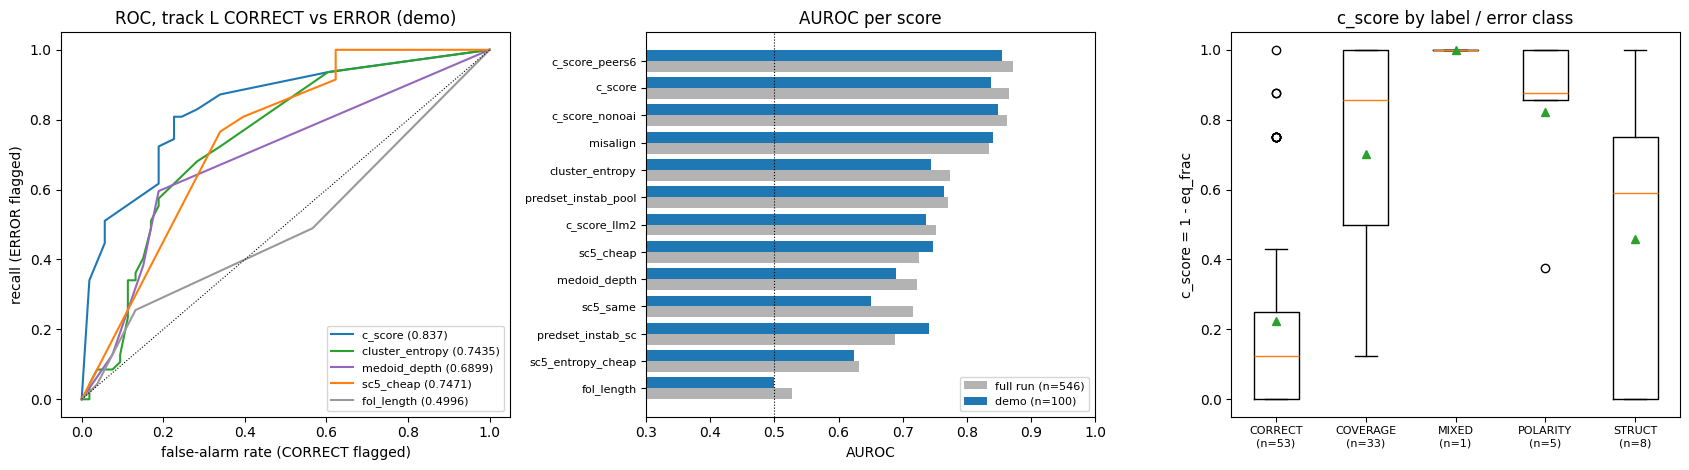


Highest-c_score candidates (flagged):
  label  c_score   medoid_ops                                                                            text                                                                                     candidate_fol                                                                                                      medoid_fol
CORRECT      1.0   [COMPOUND]              The Picuris Mountains are a mountain range in New Mexico or Texas. (MountainRange(picuris) ∧ In(picuris, newMexico)) ⊕ (MountainRange(picuris) ∧ In(picuris, texas)) (MountainRange(picuris) ∧ LocatedIn(picuris, newmexico)) ∨ (MountainRange(picuris) ∧ LocatedIn(picuris, texas))
  ERROR      1.0 [BIND, DROP]                                         The Olive Garden is a managed building.                                                               OliveGarden(x) ∧ ManagedBuilding(x)                                                                                    ManagedBuilding(oliveGarden)
 

In [23]:
full = data["full_run_headline"]
tab = []
for sc in SCORES:
    r_ = res["primary"][sc]
    tab.append({"score": sc, "n": r_.get("n"), "n_err": r_.get("n_err"), "demo_auroc": r_.get("auroc"),
                "demo_ci95": r_.get("auroc_ci95"), "full_run_auroc": full.get(sc, {}).get("auroc"),
                "full_run_ci95": full.get(sc, {}).get("auroc_ci95"), "vocab_clean_demo": res["vocab_clean"][sc].get("auroc")})
tab = pd.DataFrame(tab)
print(tab.to_string(index=False))
print(f"\ntotal notebook compute time for the pipeline cells: {time.time() - t_all:.0f}s; mean z3 seconds per candidate: {df['seconds_z3'].mean():.3f}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
# (a) ROC curves
for sc, col in (("c_score", "C0"), ("cluster_entropy", "C2"), ("medoid_depth", "C4"), ("sc5_cheap", "C1"), ("fol_length", "0.6")):
    d = P[P[sc].notna()]
    fpr, tpr, _ = roc_curve(d["y"], d[sc].astype(float))
    ax[0].plot(fpr, tpr, color=col, label=f"{sc} ({res['primary'][sc].get('auroc')})")
ax[0].plot([0, 1], [0, 1], "k:", lw=0.8)
ax[0].set(xlabel="false-alarm rate (CORRECT flagged)", ylabel="recall (ERROR flagged)", title="ROC, track L CORRECT vs ERROR (demo)")
ax[0].legend(fontsize=8, loc="lower right")
# (b) demo vs full-run AUROC
t2 = tab[tab["full_run_auroc"].notna()].sort_values("full_run_auroc")
yy = np.arange(len(t2))
ax[1].barh(yy - 0.2, t2["full_run_auroc"], 0.4, label="full run (n=546)", color="0.7")
ax[1].barh(yy + 0.2, t2["demo_auroc"], 0.4, label=f"demo (n={len(P)})", color="C0")
ax[1].set_yticks(yy, t2["score"], fontsize=8); ax[1].axvline(0.5, color="k", ls=":", lw=0.8)
ax[1].set(xlim=(0.3, 1.0), xlabel="AUROC", title="AUROC per score"); ax[1].legend(fontsize=8)
# (c) c_score distribution by label / error class
groups = [("CORRECT", P[P["y"] == 0]["c_score"])] + [(c, E[E["op_class"] == c]["c_score"]) for c in sorted(E["op_class"].unique())]
ax[2].boxplot([g for _, g in groups], showmeans=True)
ax[2].set_xticks(range(1, len(groups) + 1), [f"{n}\n(n={len(g)})" for n, g in groups], fontsize=8)
ax[2].set(ylabel="c_score = 1 - eq_frac", title="c_score by label / error class")
plt.tight_layout(); plt.show()

# a few flagged vs endorsed examples
show = P.sort_values("c_score")[["label", "c_score", "medoid_ops", "text", "candidate_fol", "medoid_fol"]]
pd.set_option("display.max_colwidth", 70)
print("\nHighest-c_score candidates (flagged):"); print(show.tail(4).to_string(index=False))
print("\nERROR candidates the consensus endorses (blind spots):"); print(show[(show["label"] == "ERROR") & (show["c_score"] == 0)].drop_duplicates("candidate_fol").head(4).to_string(index=False))